(kaggle-iterate-like-a-grandmaster)=
# Iterate Like a Grandmaster
- based on the Kaggle notebook [Iterate like a grandmaster!](https://www.kaggle.com/code/jhoward/iterate-like-a-grandmaster/)
- the goal is to give a taste of *how* a competitor might tackle tackle the [U.S. Patent Phrase to Phrase Matching competition](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/), which I explored in the notebook {ref}`kaggle_getting_started_with_nlp`
- the focus of this notebook is twofold:
    1. how to create an effective validation set
    2. how to iterate rapidly to find changes which will improve results on the validation set
- we'll be using plain HuggingFace Transformers and using as little code as possible (more code = more maintenance & more chance for mistakes)

## Download and Review Data
Download the training and evaluation datasets if not already done.  
Start by importing stuff required for data download and review.  
We will use `fastai` which includes many required libraries for AI/ML (`pd`, `np`, ...).  
The example notebook just used from fastai.imports import *, but that feels icky.

In [1]:
# Imports required for download/review data
from pathlib import Path
from fastai.imports import np, pd

In [2]:
# download and unzip the dataset to this folder if not already downloaded
data_dir = Path("us-patent-phrase-to-phrase-matching")
if not data_dir.exists():
    # import kaggle api to allow downloading dataset, zipfile to unzip
    import kaggle
    import zipfile
    # download the dataset from Kaggle as zip file
    kaggle.api.competition_download_cli(str(data_dir))
    zip_path = data_dir.with_suffix(".zip")  # path to the downloaded zip file
    zipfile.ZipFile(zip_path).extractall(data_dir)  # unzip the file
    zip_path.unlink()  # delete the zip file after unzipping

In [3]:
# look at training dataset
df = pd.read_csv(data_dir / 'train.csv')
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [4]:
# look at test set - 35 entries (why is there not a score column?)
eval_df = pd.read_csv(data_dir / 'test.csv')
print(f"entries in the test set: {len(eval_df)}")
eval_df.head()

entries in the test set: 36


,id,anchor,target,context
0,4112d61851461f60,opc drum,inorganic photoconductor drum,G02
1,09e418c93a776564,adjust gas flow,altering gas flow,F23
2,36baf228038e314b,lower trunnion,lower locating,B60
3,1f37ead645e7f0c8,cap component,upper portion,D06
4,71a5b6ad068d531f,neural stimulation,artificial neural network,H04


### Look at Targets
Looking at the distribution of values in the `target` column, there are `29,340` unique targets. 
With `36,473` entries, they're *mostly* unique. 
General phrases like `composition` are more common than stuff like `embossing device`

In [5]:
df.target.value_counts()

target
composition                    24
metal                          22
motor                          22
data                           22
assembly                       21
                               ..
cylindrical carving machine     1
embossing device                1
lumber article                  1
plywood article                 1
timber article                  1
Name: count, Length: 29340, dtype: int64

### Look at Anchors
There are far fewer `anchors` than `targets` (`733`)

In [6]:
df.anchor.value_counts()

anchor
component composite coating              152
sheet supply roller                      150
source voltage                           140
perfluoroalkyl group                     136
el display                               135
                                        ... 
shannon                                    2
plug nozzle                                2
dry coating composition1                   2
conduct conducting material                1
peripheral nervous system stimulation      1
Name: count, Length: 733, dtype: int64

### Look at Contexts
Even fewer unique `context` entries - `106`.  
They're short codes indicating stuff about the patent.  
[A47C](https://www.uspto.gov/web/patents/classification/cpc/html/cpc-A47C.html) = `A`(`Human Necessities`), `47`(`Furniture`), `C`(`chairs;sofas;beds`)  
Looks like these just use the first letter and number.  
`H01` = `H` (`Electricity`), `01` (`Electric Elements`)

In [7]:
df.context.value_counts()

context
H01    2186
H04    2177
G01    1812
A61    1477
F16    1091
       ... 
B03      47
F17      33
B31      24
A62      23
F26      18
Name: count, Length: 106, dtype: int64

The `context` is a series of short codes, the first character indicating the section the patent was filed under.  
Make a column of just that part of the context and check the distribution.  
Most common section is [B](https://www.uspto.gov/web/patents/classification/cpc/html/cpc-B.html#B) (`Performing Operations; Transporting`)

In [8]:
df['section'] = df.context.str[0]
df.section.value_counts()

section
B    8019
H    6195
G    6013
C    5288
A    4094
F    4054
E    1531
D    1279
Name: count, dtype: int64

### Look at Scores
Look at the distribution of `scores` next.  
These range from `0` (no similarity) to `1` (identical meaning).

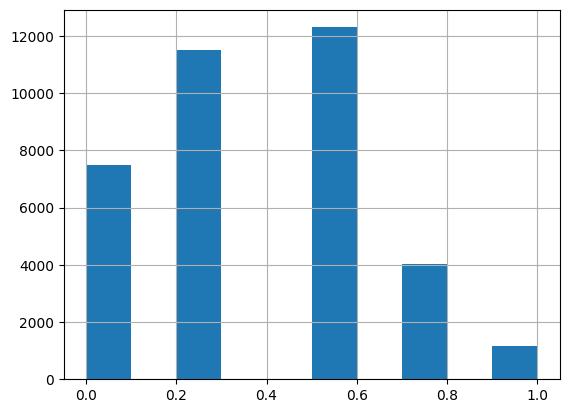

In [9]:
df.score.hist(); # the ; makes the Jupyter output shorter

A small number are scored `1.0` (identical meanings) - look at those.
They're just minor rewordings of each other - `wood`=`wooden` and the like.  
Pretrained models should find that kind of stuff already.  
We're more interested in getting them to find similarities that a normal model would miss.  
Similarities that are due to other patent details like the `context`.  

In [10]:
df[df.score==1]

,id,anchor,target,context,score,section
28,473137168ebf7484,abatement,abating,F24,1.0,F
158,621b048d70aa8867,absorbent properties,absorbent characteristics,D01,1.0,D
161,bc20a1c961cb073a,absorbent properties,absorption properties,D01,1.0,D
311,e955700dffd68624,acid absorption,absorption of acid,B08,1.0,B
315,3a09aba546aac675,acid absorption,acid absorption,B08,1.0,B
...,...,...,...,...,...,...
36398,913141526432f1d6,wiring trough,wiring troughs,F16,1.0,F
36435,ee0746f2a8ecef97,wood article,wood articles,B05,1.0,B
36440,ecaf479135cf0dfd,wood article,wooden article,B05,1.0,B
36464,8ceaa2b5c2d56250,wood article,wood article,B44,1.0,B


## Training

In [11]:
# Check if PyTorch can use GPU
import torch
print(f"PyTorch version: {torch.version.__version__}\nCUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: NVIDIA GeForce RTX 4070 Laptop GPU


In [12]:
# reduce excessive warnings from Huggingface's Transformers before importing them
import warnings
import logging
warnings.simplefilter('ignore')
logging.disable(logging.WARNING)

In [13]:
# import packages required for training
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset, DatasetDict #, load_dataset
#import transformers, logging, torch, datasets
#from torch.utils.data import DataLoader

### Choose Model
He tried to find a model that could be trained reasonably on personal hardware in a few minutes, but with reasonable accuracy, and found that `deberta-v3-small` worked.

In [14]:
# set the name of the chosen model
model_nm = 'microsoft/deberta-v3-small'

### Get Tokenizer
Pretrained models assume a particular tokenization, so get the tokenizer particular to the pretrained model.  
The Hugging Face Transformer library includes AutoTokenizer, which can load in model-specific tokenizers if you know the model's name.

In [15]:
tokz = AutoTokenizer.from_pretrained(model_nm)

We'll need a single column to use as an input, and we need the individual tokens to be saparated. 
Use the separator token specific to the model's tokenizer.

In [16]:
# grab the separator and combine the context, anchor, and target columns into a input column
sep = tokz.sep_token
print('separator token:', sep)
df['inputs'] = df.context + sep + df.anchor + sep + df.target
print('example input entry:', df.inputs[0])

separator token: [SEP]
example input entry: A47[SEP]abatement[SEP]abatement of pollution


### Convert DataFrame to Dataset
HuggingFace will perform better with one of its own DataSets instead of a Pandas DataFrame, so convert it.
Also, HuggingFace Transformers expect the output variable to be named `label`, so rename it to that from `score`.

In [17]:
# convert from DataFrames to 
ds = Dataset.from_pandas(df).rename_column('score', 'label')
eval_ds = Dataset.from_pandas(eval_df)

### Create Tokenizer Function
We'll need a function to return a tokenized version of the input.  
Testing it shows that it's added a token type ID and attention mask entry.  
Inspecting, you can see some special tokens (some of which are added on by the tokenizer):  
`1` (start of text), `2` (separator `[SEP]`), `336`=`_A`, `5753`=`47`.  

In [18]:
# define one-line function that tokenizes the inputs column of the given dataframe
def tok_func(x): return tokz(x["inputs"])
# test it on the input column of the first row
print(f'input:\n  "{ds['inputs'][0]}"\noutput:')
for key, val in tok_func(ds[0]).items():
    print(f"  {key}:{val}")

input:
  "A47[SEP]abatement[SEP]abatement of pollution"
output:
  input_ids:[1, 336, 5753, 2, 47284, 2, 47284, 265, 6435, 2]
  token_type_ids:[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  attention_mask:[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Can check out the special characters and their indices for the specific tokenizer.

In [19]:
print(tokz.all_special_tokens)
print(tokz.all_special_ids)

['[CLS]', '[SEP]', '[UNK]', '[PAD]', '[MASK]']
[1, 2, 3, 0, 128000]


### Tokenize inputs column
Tokenize the `inputs` column via `map` and the earlier `tok_func`.  
Recall that `tok_func` takes a string and runs `AutoTokenizer` on it,  
returning a dictionary with `input_ids`, `token_type_ids`, and `input_masks`.  

Use `dataset.map` to apply that function to each entry in the `inputs` column,  
adding `input_ids`, `token_type_ids`, and `input_masks` columns.

use batching to speed it up, and drop the columns we don't need -  
`anchor` and `target` are now include in `inputs`, which is itself encoded in the new tokenized columns.

All that remains are the `label` (formerly `score`, the predicted feature),  
the `input_ids` - tokenized version of inputs,  
the `token_type_ids`- which indicates whether a token is a part of the `context` or the `question`,  
and the `attention_mask`- which indicates which tokens have actual data and which are padding.

In [20]:
# tokenize the inputs column, remove now-redundant columns
inps = "anchor","target","context"
remove_cols = inps + ('inputs','id','section')
tok_ds = ds.map(tok_func, batched=True, remove_columns=remove_cols)
tok_ds[0]

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

{'label': 0.5,
 'input_ids': [1, 336, 5753, 2, 47284, 2, 47284, 265, 6435, 2],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## Creating a Validation Set
The author was watching discussion about the dataset and found a [post](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/discussion/315220) which indicated that the `test` `anchors` (by which the competition will be judged) are **not** present in the `training` `anchor` set.

To perform well in the competition, then, we should train and validate the model as close to how it will be tested - we need to pull some anchors out of the training dataset to use in the validation set. Our validation set will include unseen anchors just like the final test set.

### Shuffle the Unique Anchors
First, get a randomly shuffled list of anchors (we don't want to split off an alphabet-order-specific selection)

In [21]:
# get a randomly ordered list of unique anchors and show the first 5
anchors = df.anchor.unique()
np.random.seed(42)
np.random.shuffle(anchors)
anchors[:5]

array(['time digital signal', 'antiatherosclerotic', 'filled interior',
       'dispersed powder', 'locking formation'], dtype=object)

### Hold back 1/4 unique anchors ~1/3 rows
Grab a list of 25% of the unique anchors for the validation dataset

In [22]:
val_sz = int(len(anchors)*0.25) # determine how many ID's make up 25% of unique anchors
val_anchors = anchors[:val_sz] # grab the first however-many-id's-that-is
val_anchors[:9] # print out 10 of them. 

array(['time digital signal', 'antiatherosclerotic', 'filled interior',
       'dispersed powder', 'locking formation', 'container opener',
       'apply to anode electrode', 'pen based computer', 'running tally'],
      dtype=object)

Get a list of the rows from the DataFrame with anchors set aside for validation.  
Note that we set aside `25%` of the unique anchors, but some anchors are in more rows than others,  
so we've actually set aside `33%` of the overall data for validation.

In [23]:
is_val = np.isin(df.anchor, val_anchors) # get a True/False array of whether each row is in the validation anchor set
idxs = np.arange(len(df)) # make an array of indices [0,1,2, ... 36472]
val_idxs = idxs[ is_val] # subset that list with the entries that are True (i.e. have validation anchors)
trn_idxs = idxs[~is_val] # subset that list with the entries that are False (i.e. NOT validation anchors)
print("indices in validation array", len(val_idxs))
print("indices of non-validation array", len(trn_idxs))
print(f"{round(len(val_idxs)/len(trn_idxs)*100, 2)}% of rows reserved for validation")

indices in validation array 9116
indices of non-validation array 27357
33.32% of rows reserved for validation


### Create train/test DatasetDict
Now use those lists of validation (`test`) and non-validation (`train`) indices to make Transformers Datasets for each and put them into a DatasetDict.

In [24]:
dds = DatasetDict({
    "train": tok_ds.select(trn_idxs),
    "test":  tok_ds.select(val_idxs)
})

A lot of people do much more complex stuff when creating their validation sets, but this works fine for such a large dataset - 
as you can see, the two groups have similar average scores when you take the means of all the rows in each set.

In [25]:
print("mean score of training   set:", round(df.iloc[trn_idxs].score.mean(), 3))
print("mean score of validation set:", round(df.iloc[val_idxs].score.mean(), 3))

mean score of training   set: 0.362
mean score of validation set: 0.361


## Initial Model Training

Set the original parameters for the first attempts at training

Define a function to return success metric
- must return a dictionary so Transformers knows what label to use
- use numpy Pearson correlation coefficient
- `*eval_pred` unpacks the tuple so each element is passed as separate arg
- `[0][1]` returns the coefficient from the top right of the 2D array

In [26]:
# define function to return success metric
def corr(eval_pred):
    return {'pearson': np.corrcoef(*eval_pred)[0][1]}

Set initial hyperparameters
- learning rate and  batch size that will fit the GPU
- reasonable weight decay
- small number of epochs (4 isn't much, but most of the progress can be made in that time, so it's good for experimentation)

In [27]:
# define hyperparameters for initial training attempt
lr = 8e-5  # learning rate
bs = 128   # batch size
wd = 0.01  # weight decay
epochs = 4 # number of epochs

### Create TrainingArguments
Transformers use the `TrainingArguments` class to set up arguments,  
and `Trainer` class to combine the model, data, and training args together.

In [28]:
# create TrainingArguments to pass to Trainer
args = TrainingArguments(
    'outputs', 
    learning_rate=8e-5, # decent learning rate for the GPU
    warmup_ratio=0.1, 
    lr_scheduler_type='cosine', # fast.ai has found this warmup scheduler to be reliable
    fp16=True, # fp16 is faster for modern GPU's and saves memory
    eval_strategy="epoch", 
    per_device_train_batch_size=bs, 
    per_device_eval_batch_size=bs*2, # eval stage doesn't store gradients, can do 2x the rows at once
    num_train_epochs=epochs, 
    weight_decay=0.01, # set reasonable weight decay
    report_to='none')
# Create Model to add to Trainer (use the name from earlier)
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)
# Create the Trainer with the model, training args, datasets, tokenizer, metrics function
trainer = Trainer(
    model, args, # pass it the args and model we just put together
    train_dataset=dds['train'], # get train dataset from DatasetDict
    eval_dataset=dds['test'],   # get eval  dataset from DatasetDict
    tokenizer=tokz, # it needs the tokenizer 
    compute_metrics=corr) # here's the Pearson correlation function we made

### Train!
Well it looks like enabling the GPU helped ... a similar training operation in {ref}`kaggle_getting_started_with_nlp` took 55 minutes. This took less than 2. The version up on Kaggle took a little more than 4. Got it enabled by using UV to install the correct version of PyTorch for my version of CUDA (see [Local Pytorch](https://pytorch.org/get-started/locally) and [Using UV with PyTorch](https://docs.astral.sh/uv/guides/integration/pytorch/)) and restarting the kernel

So the final Pearson Coefficient gets up to `0.813`,`0.812`, ... Decent starting point!

In [29]:
trainer.train(); # the ; makes the output a bit shorter since it makes Jupyter think there's another line

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.026294,0.795718
2,No log,0.024560,0.806296
3,0.036800,0.026141,0.811804
4,0.036800,0.025526,0.811735


## Improving the Model
1. First step before improving: determine whether model results are stable. The original writer did the training 3 times and got a pretty stable Pearson coefficient (`0.808`-`0.810`), which is stable enough to use as a base, and also tells us that improvements need to be better than that range to be worth it.
2. Make some rapid iterations, trying out different data processing and trainer parameters
3. Once we're confident we've got the basics right, train with more epochs and do some cross validation

### Create Functions for Rapid Iteration

In [30]:
# Create a function to rapidly apply tokenization and set the DatasetDict
def get_dds(df):
    # convert to Dataset, rename 'score' column to 'label' like HuggingFace Transformers expects
    ds = Dataset.from_pandas(df).rename_column('score', 'label')
    # tokenize the 'inputs' column, remove unnneeded columns
    tok_ds = ds.map(tok_func, batched=True, remove_columns=inps+('inputs','id','section'))
    # split into test and train datasets, return in a DatasetDict
    return DatasetDict({"train":tok_ds.select(trn_idxs), "test": tok_ds.select(val_idxs)})

# create a function to create the Model
def get_model(): 
    return AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)

# create a function to create the Trainer
def get_trainer(dds, model=None):
    # Set the model, use the pretrained one if nothing else specified
    if model is None: 
        model = get_model()
    # Create the TrainingArguments
    args = TrainingArguments(
        'outputs', learning_rate=lr, warmup_ratio=0.1,
        lr_scheduler_type='cosine', fp16=True, eval_strategy="epoch", 
        per_device_train_batch_size=bs, per_device_eval_batch_size=bs*2,
        num_train_epochs=epochs, weight_decay=wd, report_to='none')
    # Make the Trainer from the 
    return Trainer(
        model, args, 
        train_dataset=dds['train'], 
        eval_dataset=dds['test'], 
        tokenizer=tokz, compute_metrics=corr)

### Try a different Separator
Maybe we should use a custom separator character instead of the one that the model uses.  
Change the `inputs` column to use that instead, then make and train a new model

In [31]:
# Make a Datasetdict with a new separator, then create and train a new model with it
sep = " [s] "
df['inputs'] = df.context + sep + df.anchor + sep + df.target
dds = get_dds(df)
get_trainer(dds).train()

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.026878,0.799777
2,No log,0.023914,0.813574
3,0.029500,0.024880,0.816018
4,0.029500,0.024308,0.818810


TrainOutput(global_step=856, training_loss=0.02263424329668562, metrics={'train_runtime': 105.1651, 'train_samples_per_second': 1040.536, 'train_steps_per_second': 8.14, 'total_flos': 581591382621300.0, 'train_loss': 0.02263424329668562, 'epoch': 4.0})

Hey, `0.818` is better than `0.813`, let's keep that change  
(normally you'd run it a few times to see if it was consistent)

### Patent Section Tokens
maybe add the patent section as a new special token so the model will learn to handle different sections different ways  
i.e. create a token `[A]` for section `A`, add all sections as their own special characters

In [32]:
df['sectok'] = '[' + df.section + ']' # make a column with '[A]' etc
sectoks = list(df.sectok.unique()) # get a list of all unique entries in that column
tokz.add_special_tokens({'additional_special_tokens': sectoks}) # add to tokenizer

8

In [ ]:
# add that section token to the beginning of the inputs column
df['inputs'] = df.sectok + sep + df.anchor.str.lower() + sep + df.target
dds = get_dds(df) # create a new DatasetDictionary from the 'inputs'

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

In [34]:
# resize the model embedding matrix in the model since we've added more tokens
model = get_model()
model.resize_token_embeddings(len(tokz))

Embedding(128009, 768, padding_idx=0)

New embedding has a vocab size of 128009 and 768 embedding dimensions.  
So each token is represented by a vector of 768 numbers.  
And there are 128009 tokens that it knows how to handle.  
They're stored in a 2D matrix.  

Note that we haven't actually told it what those tokens *are* yet.  
We've just told it how big it needs to be.  
It's copied the initial embeddings over, the new ones are randomized.  
We'll train the vectors of the new tokens now.  

In [35]:
# must pass the new model with the expanded vocab to train
trainer = get_trainer(dds, model=model)
trainer.train()

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.027168,0.801552
2,No log,0.023376,0.817448
3,0.029500,0.024142,0.819981
4,0.029500,0.023861,0.820306


TrainOutput(global_step=856, training_loss=0.02270349888043983, metrics={'train_runtime': 103.1412, 'train_samples_per_second': 1060.953, 'train_steps_per_second': 8.299, 'total_flos': 553279077275580.0, 'train_loss': 0.02270349888043983, 'epoch': 4.0})

Well that slightly improved Pearson (`0.8186`->`0.8203`) and Validation Loss again (`0.0246`->`0.0238`).  Keep that one!

### Some Other Ideas
- Try a model pretrained on legal vocabulary, like [BERT for patents](https://huggingface.co/anferico/bert-for-patents)
- Try a sentence similarity model, like this [patent similarity model](https://huggingface.co/AI-Growth-Lab/PatentSBERTa)
- fine-tune any HuggingFace model with the full patent database (provided in BigQuery) before applying it to this dataset
- Replace the patent context field with the *description* of that context provided by the patent office

## Cross Validation
Now that we've got some obvious improvements out of the way, we'll need a way to evaluate smaller changes.  
Try [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html#sklearn.model_selection.StratifiedGroupKFold)  
It will try non-overlapping anchors (I guess that means that each type of anchor will be put into a group together instead of being divided through the other groups?)

In [36]:
# create a cross validator that can be used to split up the data
from sklearn.model_selection import StratifiedGroupKFold
n_folds = 4
cv = StratifiedGroupKFold(n_splits=n_folds)

In [37]:
# split the DataFrame into folds
df = df.sample(frac=1, random_state=42) # shuffle the rows (frac=1->all)
scores = (df.score*100).astype(int) # get scores as integers 0-100
# use the cross validator to split the dataframe up
# idxs = the row indices (not shuffled, just an array with same rows as data)
# scores = will make the folds have similar (average?) scores
# using anchor will tell it to give the folds non-overlapping anchors
folds = list(cv.split(idxs, scores, df.anchor))
folds

[(array([    0,     1,     2, ..., 36469, 36471, 36472], shape=(27346,)),
  array([    8,    13,    14, ..., 36453, 36464, 36470], shape=(9127,))),
 (array([    0,     1,     5, ..., 36470, 36471, 36472], shape=(27368,)),
  array([    2,     3,     4, ..., 36459, 36461, 36462], shape=(9105,))),
 (array([    1,     2,     3, ..., 36467, 36470, 36472], shape=(27351,)),
  array([    0,     7,    11, ..., 36468, 36469, 36471], shape=(9122,))),
 (array([    0,     2,     3, ..., 36469, 36470, 36471], shape=(27354,)),
  array([    1,     5,     9, ..., 36465, 36467, 36472], shape=(9119,)))]

so `folds` is now a list of pairs of arrays.  
the first array in each pair are indices of training rows for the fold  
and the second array in each pair has indices of the validation rows

In [38]:
# create a function to turn those folds into DatasetDicts
def get_fold(folds, fold_num):
    trn,val = folds[fold_num] # get the arrays of train and test indices for this fold
    return DatasetDict({ # create a DatasetDict for this fold by selecting the right indices
        "train":tok_ds.select(trn), # first array has train indices
        "test": tok_ds.select(val)}) # second array has validation indices

In [39]:
# try it out - get a DatsetDict for the 1st fold
dds = get_fold(folds, 0)
dds

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27346
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9127
    })
})

Looks good, can pass those Datasetdicts to the trainer to train models.  
4 folds would allow you to get four models / predictions/ metrics.  
Could ensemble the 4 models into one stronger model.  
Could average the 4 metrics to get a more accurate assessment of of your model's scores.

Here's how you'd extract the final epoch matrices from a trainer:  
`trainer.state.log_history` will have a dictionary of metrics like `eval_pearson` and `train_loss` for various points during training  
(like each epoch and specific step counts).  
This routine grabs the dictionary entries for `eval_pearson` and just takes the last one (which is the final one)

In [40]:
metrics = [o['eval_pearson'] for o in trainer.state.log_history if 'eval_pearson' in o]
metrics[-1]

0.8203060258366008

In [41]:
# try it - train one model per fold and get the pearson coefficient from each
pearsons = []
for i in range(len(folds)):
    # extract the DatasetDictionary for the current fold
    dds = get_fold(folds, i)
    # reset model to remove training from prior folds, prep it for added section tokens
    model = get_model()
    model.resize_token_embeddings(len(tokz))
    # create the trainer and train the model for this fold
    trainer = get_trainer(dds, model=model)
    trainer.train()
    # grab the pearson correlation coefficient metric from the last epoch for this fold
    metrics = [o['eval_pearson'] for o in trainer.state.log_history if 'eval_pearson' in o]
    pearsons.append(metrics[-1])

Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.028959,0.796531
2,No log,0.021608,0.826423
3,0.029500,0.022120,0.835105
4,0.029500,0.022173,0.837116


Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.028108,0.797522
2,No log,0.023575,0.825913
3,0.030100,0.020953,0.835904
4,0.030100,0.022182,0.834707


Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.031778,0.804915
2,No log,0.022355,0.828921
3,0.030400,0.020830,0.838763
4,0.030400,0.021541,0.840206


Epoch,Training Loss,Validation Loss,Pearson
1,No log,0.030300,0.789697
2,No log,0.022839,0.827026
3,0.030100,0.021869,0.840002
4,0.030100,0.022103,0.840160


In [42]:
print("pearson correlation coefficients:")
for i, pearson in enumerate(pearsons):
    print(f" fold {i+1}:", pearson)
print("average:", sum(pearsons) / len(pearsons))

pearson correlation coefficients:
 fold 1: 0.8371156314367642
 fold 2: 0.8347067460331601
 fold 3: 0.8402059401372125
 fold 4: 0.8401595556913395
average: 0.838046968324619


Interesting, each individual cross-validation fold was better than the full set.  
Perhaps each dataset was more uniform as anchors were concentrated in each one.  
Testing the model trained on the final fold on the full eval dataset,  
the pearson coefficient is higher than before, though so is the loss.

In [59]:
# test using the model trained on the last fold on the full evaluation dataset
eval_ds = get_dds(df)["test"]
preds = trainer.predict(eval_ds)
print(preds)
print("pearson:", preds.metrics["test_pearson"])

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

PredictionOutput(predictions=array([0.57373047, 0.47436523, 0.37548828, ..., 0.49169922, 0.5595703 ,
       0.5161133 ], shape=(9116,), dtype=float32), label_ids=array([0.75, 0.5 , 0.25, ..., 0.5 , 0.75, 0.5 ],
      shape=(9116,), dtype=float32), metrics={'test_loss': 0.027417922392487526, 'test_pearson': 0.8258443410264497, 'test_runtime': 2.3694, 'test_samples_per_second': 3847.385, 'test_steps_per_second': 15.194})
pearson: 0.8258443410264497


Later on I _should_ try ensembling the fold models together.